In [ ]:
import pickle
import os
DATASET_NAMES = ["mmlu_high_school", "mmlu_professional", "ARC-Challenge", "ARC-Easy", "sms_spam"]
MODEL_NAMES = ["Apertus-8B-Instruct-2509", "Llama-3.1-8B-Instruct"]
ENDINGS = ["hs", "pro", "arc_challenge"]
DS_INDEX = 0
MODEL_INDEX = 0
DATASET_NAME = DATASET_NAMES[DS_INDEX]
MODEL = MODEL_NAMES[MODEL_INDEX]
TRANSFORM = False
ENDING = "transform" if TRANSFORM else "leave"


llama_path = f"/users/astepancic/projects/apertus-probes/scratch/mera-runs/{DATASET_NAME}/{MODEL_NAMES[1]}/df_probes_{ENDING}.pkl"
apertus_path = f"/users/astepancic/projects/apertus-probes/scratch/mera-runs/{DATASET_NAME}/{MODEL_NAMES[0]}/df_probes_{ENDING}.pkl"
# Expand $SCRATCH environment variable if present in the path

with open(path, 'rb') as file:
    results = pickle.load(file)
results.head()


,Dataset,LLM_model,Task,Model,Inputs,Error-Type,Layer,Residuals,Coefficients,Nonzero-Features,...,AUCROC,Accuracy,Accuracy (Balanced),Dummy-AUCROC,Dummy-Accuracy,Dummy-Accuracy (Balanced),RMSE,MSE,Dummy-RMSE,Dummy-MSE
0,mmlu_professional,meta-llama/Llama-3.1-8B-Instruct,classification,LogReg-l1,activations,sm,0,[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,0.557430,0.642778,0.557430,0.5,0.631753,0.5,NaN,NaN,NaN,NaN
1,mmlu_professional,meta-llama/Llama-3.1-8B-Instruct,classification,LogReg-l1,activations,sm,0,[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,0.540259,0.649394,0.540259,0.5,0.629548,0.5,NaN,NaN,NaN,NaN
2,mmlu_professional,meta-llama/Llama-3.1-8B-Instruct,classification,LogReg-l1,activations,sm,0,[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,0.563767,0.668137,0.563767,0.5,0.639471,0.5,NaN,NaN,NaN,NaN
3,mmlu_professional,meta-llama/Llama-3.1-8B-Instruct,classification,LogReg-l1,activations,sm,0,[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,0.555622,0.654906,0.555622,0.5,0.628445,0.5,NaN,NaN,NaN,NaN
4,mmlu_professional,meta-llama/Llama-3.1-8B-Instruct,classification,LogReg-l1,activations,sm,0,[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,0.547611,0.631753,0.547611,0.5,0.605292,0.5,NaN,NaN,NaN,NaN


Plot saved to rmse_comparison_Llama-3.1-8B-Instruct_leave_exact.png
Plot saved to rmse_comparison_Llama-3.1-8B-Instruct_leave_last.png


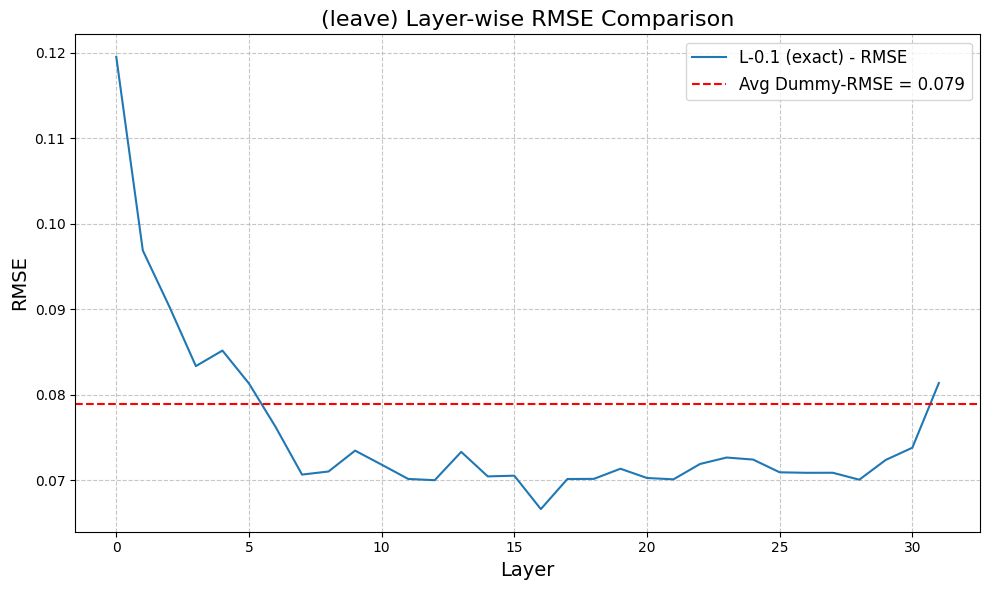

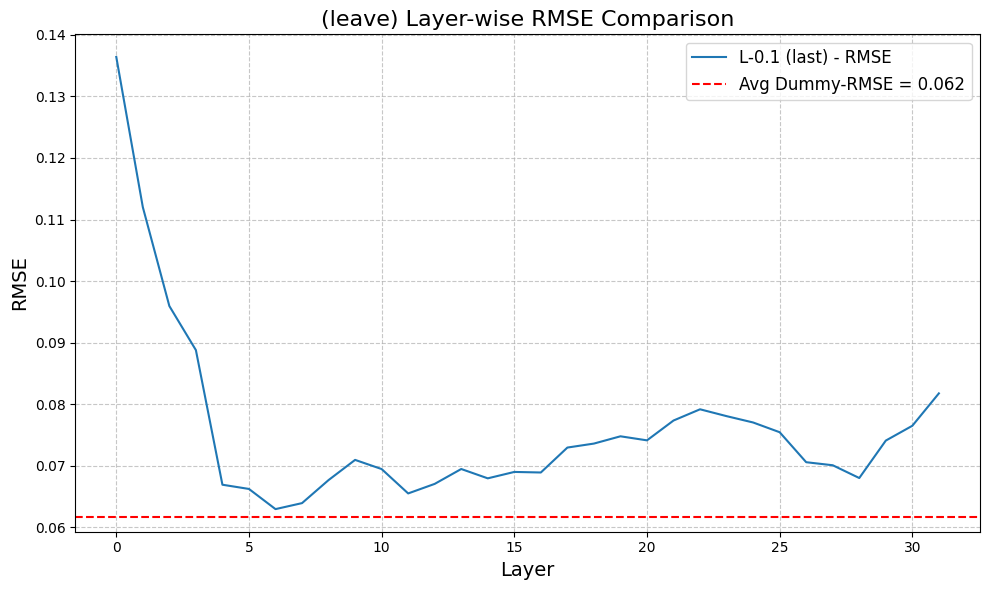

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_rmse_comparison(grouped_data, models_to_plot, token_positions, save_path=None):
    plt.figure(figsize=(10, 6))

    # One avg Dummy-RMSE across the selected models/token positions
    mask = grouped_data['Token-Pos'].isin(token_positions)
    if models_to_plot is not None:
        mask &= grouped_data['Model'].isin(models_to_plot)
    dummy_rmse = pd.to_numeric(grouped_data.loc[mask, 'Dummy-RMSE'], errors='coerce').mean()

    for model in models_to_plot:
        for token_pos in token_positions:
            group = grouped_data[(grouped_data['Model'] == model) & (grouped_data['Token-Pos'] == token_pos)]
            if group.empty:
                continue

            # Mean RMSE per layer
            layer_rmse = group.groupby('Layer')['RMSE'].mean()
            if layer_rmse.empty:
                continue

            plt.plot(
                layer_rmse.index,
                layer_rmse.values,
                label=f'{model} ({token_pos}) - RMSE'
            )

    # Plot a single Dummy-RMSE line
    if not np.isnan(dummy_rmse):
        plt.axhline(y=dummy_rmse, color='red', linestyle='--', linewidth=1.5,
                    label=f'Avg Dummy-RMSE = {dummy_rmse:.3f}')

    plt.title(f'({ENDING}) Layer-wise RMSE Comparison', fontsize=16)
    plt.xlabel('Layer', fontsize=14)
    plt.ylabel('RMSE', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"Plot saved to {save_path}")

# Example usage
models_to_plot = ['L-0.1']
token_positions = ['exact'] # Replace with actual token positions
save_path = f"rmse_comparison_{MODEL}_{ENDING}"
plot_rmse_comparison(results, models_to_plot, token_positions, save_path=save_path +'_exact.png')
token_positions = ['last']
plot_rmse_comparison(results, models_to_plot, token_positions, save_path=save_path + '_last.png')


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_rmse_both_models(grouped_data: pd.DataFrame, models_to_plot, token_positions, title=None, save_path=None):
    # Ensure list-like
    models_to_plot = list(models_to_plot)
    token_positions = list(token_positions)

    npos = len(token_positions)
    fig, axes = plt.subplots(1 if npos == 1 else npos, 1, figsize=(10, 6 if npos == 1 else 5*npos), squeeze=False)
    axes = axes.ravel()

    for ax, token_pos in zip(axes, token_positions):
        # Dummy-RMSE across selected models for this token position
        mask = (grouped_data['Token-Pos'] == token_pos) & (grouped_data['Model'].isin(models_to_plot))
        dummy_rmse = pd.to_numeric(grouped_data.loc[mask, 'Dummy-RMSE'], errors='coerce').mean()

        # Plot each model’s RMSE per layer
        for model in models_to_plot:
            gmask = (grouped_data['Model'] == model) & (grouped_data['Token-Pos'] == token_pos)
            group = grouped_data.loc[gmask]
            if group.empty:
                continue

            layer_rmse = (
                group.groupby('Layer')['RMSE']
                .apply(lambda s: pd.to_numeric(s, errors='coerce').mean())
                .sort_index()
            )
            if layer_rmse.empty:
                continue

            ax.plot(layer_rmse.index, layer_rmse.values, marker='o', linewidth=1.5, label=f'{model}')

        # Single Dummy-RMSE line
        if not np.isnan(dummy_rmse):
            ax.axhline(y=dummy_rmse, color='red', linestyle='--', linewidth=1.5,
                       label=f'Avg Dummy-RMSE = {dummy_rmse:.3f}')

        ax.set_title(f'{title or "Layer-wise RMSE"} — Token-Pos: {token_pos}', fontsize=13)
        ax.set_xlabel('Layer')
        ax.set_ylabel('RMSE')
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend(fontsize=10)

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300)
        print(f"Plot saved to {save_path}")
    return fig

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_accuracy_comparison(grouped_data, models_to_plot, token_positions, metric='Accuracy', save_path=None):
    """
    Plot accuracy comparison across layers for different models and token positions.
    
    Parameters:
    -----------
    grouped_data : pd.DataFrame
        DataFrame containing probe results with columns: Model, Token-Pos, Layer, Accuracy/AUCROC, Dummy-Accuracy/Dummy-AUCROC
    models_to_plot : list
        List of model names to plot (e.g., ['LogReg-l1'])
    token_positions : list
        List of token positions to plot (e.g., ['exact', 'last'])
    metric : str, default='Accuracy'
        Metric to plot: 'Accuracy', 'AUCROC', or 'Accuracy (Balanced)'
    save_path : str, optional
        Path to save the plot
    """
    plt.figure(figsize=(10, 6))
    
    # Filter for classification task
    if 'Task' in grouped_data.columns:
        grouped_data = grouped_data[grouped_data['Task'] == 'classification']
    
    # Determine dummy metric column name
    dummy_metric = f'Dummy-{metric}'
    
    # One avg Dummy-Accuracy across the selected models/token positions
    mask = grouped_data['Token-Pos'].isin(token_positions)
    if models_to_plot is not None:
        mask &= grouped_data['Model'].isin(models_to_plot)
    dummy_acc = pd.to_numeric(grouped_data.loc[mask, dummy_metric], errors='coerce').mean()

    for model in models_to_plot:
        for token_pos in token_positions:
            group = grouped_data[(grouped_data['Model'] == model) & (grouped_data['Token-Pos'] == token_pos)]
            if group.empty:
                continue

            # Mean Accuracy per layer
            layer_acc = group.groupby('Layer')[metric].mean()
            if layer_acc.empty:
                continue

            plt.plot(
                layer_acc.index,
                layer_acc.values,
                marker='o',
                label=f'{model} ({token_pos}) - {metric}'
            )

    # Plot a single Dummy-Accuracy line
    if not np.isnan(dummy_acc):
        plt.axhline(y=dummy_acc, color='red', linestyle='--', linewidth=1.5,
                    label=f'Avg Dummy-{metric} = {dummy_acc:.3f}')

    plt.title(f'({ENDING}) Layer-wise {metric} Comparison', fontsize=16)
    plt.xlabel('Layer', fontsize=14)
    plt.ylabel(metric, fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"Plot saved to {save_path}")


def plot_accuracy_both_models(grouped_data: pd.DataFrame, models_to_plot, token_positions, 
                               metric='Accuracy', title=None, save_path=None):
    """
    Plot accuracy comparison for multiple models across different token positions.
    
    Parameters:
    -----------
    grouped_data : pd.DataFrame
        DataFrame containing probe results
    models_to_plot : list
        List of model names to plot
    token_positions : list
        List of token positions to plot
    metric : str, default='Accuracy'
        Metric to plot: 'Accuracy', 'AUCROC', or 'Accuracy (Balanced)'
    title : str, optional
        Custom title for the plot
    save_path : str, optional
        Path to save the plot
    """
    # Filter for classification task
    if 'Task' in grouped_data.columns:
        grouped_data = grouped_data[grouped_data['Task'] == 'classification']
    
    # Ensure list-like
    models_to_plot = list(models_to_plot)
    token_positions = list(token_positions)
    
    # Determine dummy metric column name
    dummy_metric = f'Dummy-{metric}'

    npos = len(token_positions)
    fig, axes = plt.subplots(1 if npos == 1 else npos, 1, figsize=(10, 6 if npos == 1 else 5*npos), squeeze=False)
    axes = axes.ravel()

    for ax, token_pos in zip(axes, token_positions):
        # Dummy-Accuracy across selected models for this token position
        mask = (grouped_data['Token-Pos'] == token_pos) & (grouped_data['Model'].isin(models_to_plot))
        dummy_acc = pd.to_numeric(grouped_data.loc[mask, dummy_metric], errors='coerce').mean()

        # Plot each model's Accuracy per layer
        for model in models_to_plot:
            gmask = (grouped_data['Model'] == model) & (grouped_data['Token-Pos'] == token_pos)
            group = grouped_data.loc[gmask]
            if group.empty:
                continue

            layer_acc = (
                group.groupby('Layer')[metric]
                .apply(lambda s: pd.to_numeric(s, errors='coerce').mean())
                .sort_index()
            )
            if layer_acc.empty:
                continue

            ax.plot(layer_acc.index, layer_acc.values, marker='o', linewidth=1.5, label=f'{model}')

        # Single Dummy-Accuracy line
        if not np.isnan(dummy_acc):
            ax.axhline(y=dummy_acc, color='red', linestyle='--', linewidth=1.5,
                       label=f'Avg Dummy-{metric} = {dummy_acc:.3f}')

        ax.set_title(f'{title or f"Layer-wise {metric}"} — Token-Pos: {token_pos}', fontsize=13)
        ax.set_xlabel('Layer')
        ax.set_ylabel(metric)
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend(fontsize=10)

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300)
        print(f"Plot saved to {save_path}")
    return fig


In [ ]:
# Example usage for accuracy analysis
# Note: Make sure your results dataframe contains classification task results

# Filter for classification task if needed
if 'Task' in results.columns:
    classification_results = results[results['Task'] == 'classification']
else:
    classification_results = results

# Plot Accuracy
models_to_plot = ['LogReg-l1']  # Classification model
token_positions = ['exact']
save_path = f"accuracy_comparison_{MODEL}_{ENDING}"
plot_accuracy_comparison(classification_results, models_to_plot, token_positions, 
                         metric='Accuracy', save_path=save_path + '_exact.png')

token_positions = ['last']
plot_accuracy_comparison(classification_results, models_to_plot, token_positions, 
                         metric='Accuracy', save_path=save_path + '_last.png')

# Plot AUCROC
plot_accuracy_comparison(classification_results, models_to_plot, ['exact'], 
                         metric='AUCROC', save_path=f"aucroc_comparison_{MODEL}_{ENDING}_exact.png")
plot_accuracy_comparison(classification_results, models_to_plot, ['last'], 
                         metric='AUCROC', save_path=f"aucroc_comparison_{MODEL}_{ENDING}_last.png")

# Plot Accuracy (Balanced)
plot_accuracy_comparison(classification_results, models_to_plot, ['exact'], 
                         metric='Accuracy (Balanced)', save_path=f"balanced_accuracy_comparison_{MODEL}_{ENDING}_exact.png")
plot_accuracy_comparison(classification_results, models_to_plot, ['last'], 
                         metric='Accuracy (Balanced)', save_path=f"balanced_accuracy_comparison_{MODEL}_{ENDING}_last.png")


In [ ]:
# Example usage for comparing accuracy across multiple models
# This is useful when you have results from multiple models (e.g., Apertus and Llama)

# Load results from both models if available
try:
    with open(llama_path, 'rb') as f:
        llama_results = pickle.load(f)
    with open(apertus_path, 'rb') as f:
        apertus_results = pickle.load(f)
    
    # Combine results if needed
    if 'Task' in llama_results.columns:
        combined_results = pd.concat([llama_results, apertus_results])
    else:
        combined_results = pd.concat([llama_results, apertus_results])
    
    # Filter for classification
    if 'Task' in combined_results.columns:
        combined_classification = combined_results[combined_results['Task'] == 'classification']
    else:
        combined_classification = combined_results
    
    # Plot accuracy comparison for both models
    models_to_plot = ['LogReg-l1']
    token_positions = ['exact', 'last']
    
    plot_accuracy_both_models(
        combined_classification, 
        models_to_plot, 
        token_positions,
        metric='Accuracy',
        title=f'Accuracy Comparison - {DATASET_NAME}',
        save_path=f"accuracy_both_models_{DATASET_NAME}_{ENDING}.png"
    )
    
    # Plot AUCROC comparison
    plot_accuracy_both_models(
        combined_classification, 
        models_to_plot, 
        token_positions,
        metric='AUCROC',
        title=f'AUCROC Comparison - {DATASET_NAME}',
        save_path=f"aucroc_both_models_{DATASET_NAME}_{ENDING}.png"
    )
    
except FileNotFoundError as e:
    print(f"Could not load one or both result files: {e}")
    print("Make sure both llama_path and apertus_path are correctly set.")
